In [ ]:
import numpy as np
from PIL import Image
import os

# Create directories for skin tones
skin_tone_categories = ['light_skin', 'medium_skin', 'dark_skin']
for tone in skin_tone_categories:
    os.makedirs(f'skin_tone_dataset/{tone}', exist_ok=True)

# Create directories for undertones
undertone_categories = ['neutral', 'warm', 'cool']
for undertone in undertone_categories:
    os.makedirs(f'undertone_dataset/{undertone}', exist_ok=True)

# Function to generate synthetic skin tone images
def generate_synthetic_skin_images():
    # Generate synthetic skin tone images
    for tone in skin_tone_categories:
        for _ in range(100):  # Generate 100 images per skin tone category
            if tone == 'light_skin':
                color = np.array([255, 224, 200]) + np.random.randint(-15, 15, 3)  # Light skin tones
            elif tone == 'medium_skin':
                color = np.array([200, 150, 120]) + np.random.randint(-15, 15, 3)  # Medium skin tones
            else:  # dark_skin
                color = np.array([150, 100, 80]) + np.random.randint(-15, 15, 3)  # Dark skin tones

            img = Image.new('RGB', (128, 128), tuple(color))
            img.save(f'skin_tone_dataset/{tone}/synthetic_{_}.jpg')

    # Generate synthetic undertone images
    for undertone in undertone_categories:
        for _ in range(100):  # Generate 100 images per undertone category
            if undertone == 'warm':
                color = np.array([255, 224, 200]) + np.random.randint(-15, 15, 3)  # Warm undertones
            elif undertone == 'neutral':
                color = np.array([200, 160, 140]) + np.random.randint(-15, 15, 3)  # Neutral undertones
            else:  # cool
                color = np.array([170, 140, 120]) + np.random.randint(-15, 15, 3)  # Cool undertones

            img = Image.new('RGB', (128, 128), tuple(color))
            img.save(f'undertone_dataset/{undertone}/synthetic_{_}.jpg')

# Generate synthetic images
generate_synthetic_skin_images()

In [ ]:
pip install opencv-python

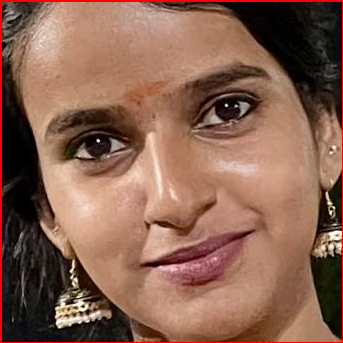

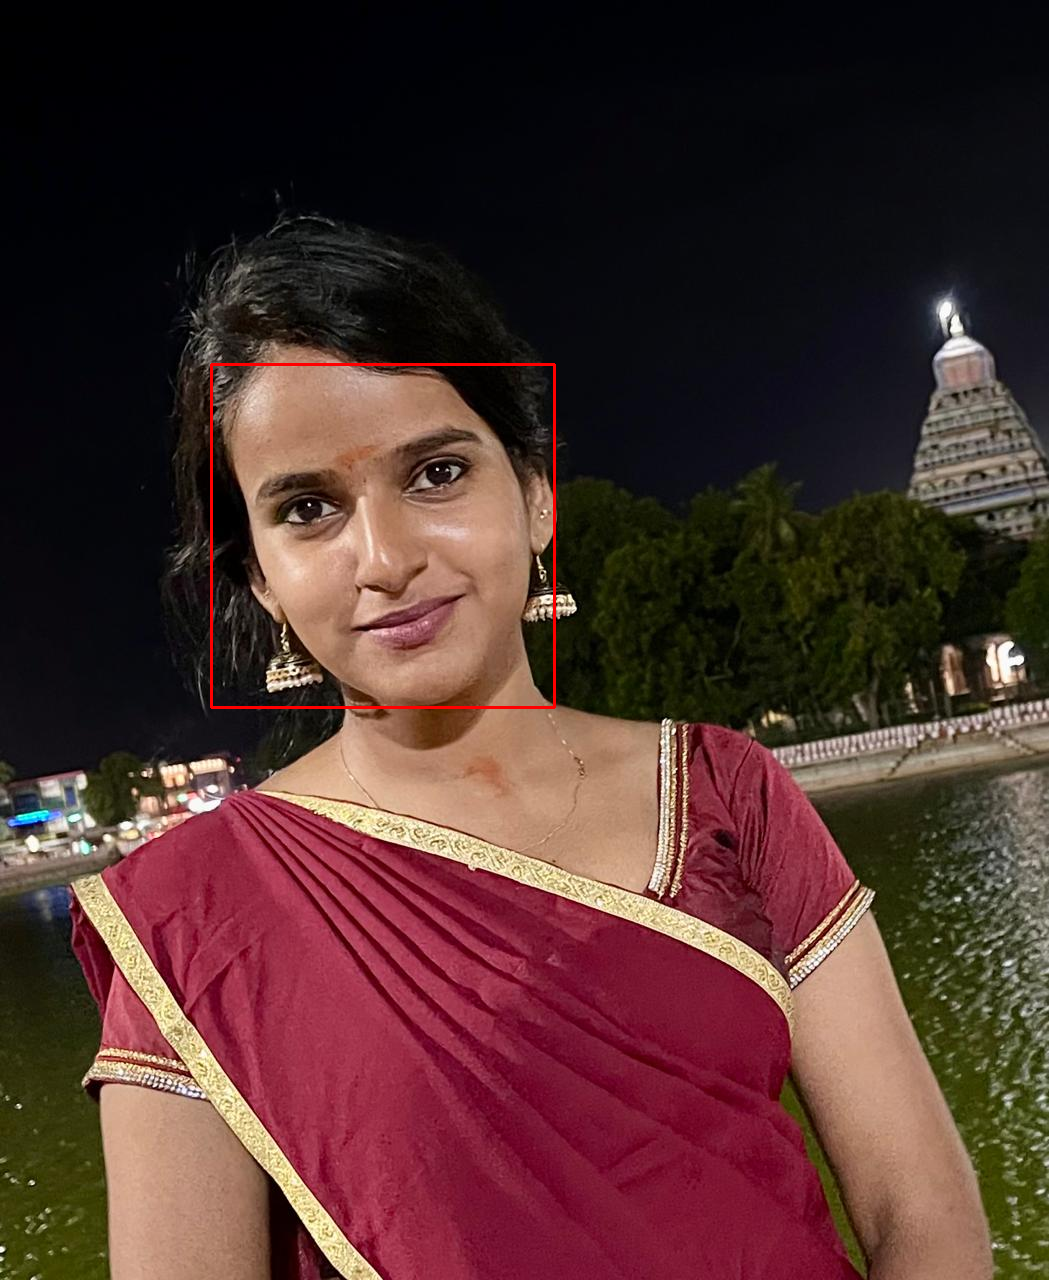

In [ ]:
import cv2
from google.colab.patches import cv2_imshow  # Use cv2_imshow instead of cv2.imshow

# Load the image you provided
img = cv2.imread('/content/vidya.jpg')

# Convert the image to grayscale (Haar Cascade works better on grayscale images)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Load the pre-trained face detection model
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_alt2.xml')

# Perform face detection
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Check if any faces are detected
if len(faces) > 0:
    # Iterate over all detected faces
    for (x, y, w, h) in faces:
        # Draw a rectangle around each face
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)

        # Crop the face out of the image
        face_crop = img[y:y + h, x:x + w]

        # Display the cropped face using cv2_imshow
        cv2_imshow(face_crop)

        # Save the cropped face as a new image
        cv2.imwrite('cropped_face.jpg', face_crop)

    # Display the original image with rectangles around detected faces using cv2_imshow
    cv2_imshow(img)
else:
    print("No faces detected.")


In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Function to load images and their corresponding labels
def load_images(image_dir, categories):
    data = []
    labels = []

    for label, category in enumerate(categories):
        folder_path = os.path.join(image_dir, category)
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            img = Image.open(img_path).resize((128, 128))
            img_array = np.array(img)
            data.append(img_array)
            labels.append(label)

    return np.array(data), np.array(labels)

# Load skin tone dataset
skin_tone_data, skin_tone_labels = load_images('skin_tone_dataset', ['light_skin', 'medium_skin', 'dark_skin'])

# Load undertone dataset
undertone_data, undertone_labels = load_images('undertone_dataset', ['neutral', 'warm', 'cool'])

# Normalize the data
skin_tone_data = skin_tone_data / 255.0
undertone_data = undertone_data / 255.0

# One-hot encode the labels
skin_tone_labels = to_categorical(skin_tone_labels, 3)
undertone_labels = to_categorical(undertone_labels, 3)


In [ ]:
# Split the data into training and testing sets
X_train_tone, X_test_tone, y_train_tone, y_test_tone = train_test_split(skin_tone_data, skin_tone_labels, test_size=0.2, random_state=42)
X_train_under, X_test_under, y_train_under, y_test_under = train_test_split(undertone_data, undertone_labels, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Model architecture for skin tone classification
def create_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D(2, 2))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))  # 3 classes (light, medium, dark)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
# Create and train skin tone model
skin_tone_model = create_model()

skin_tone_model.fit(X_train_tone, y_train_tone, epochs=10, validation_data=(X_test_tone, y_test_tone))

# Create and train undertone model
undertone_model = create_model()

undertone_model.fit(X_train_under, y_train_under, epochs=10, validation_data=(X_test_under, y_test_under))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3112 - loss: 1.4023 - val_accuracy: 0.3667 - val_loss: 1.0248
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4035 - loss: 1.0081 - val_accuracy: 0.7000 - val_loss: 0.7147
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 887ms/step - accuracy: 0.7064 - loss: 0.6778 - val_accuracy: 0.8167 - val_loss: 0.4246
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 873ms/step - accuracy: 0.8437 - loss: 0.3986 - val_accuracy: 0.8000 - val_loss: 0.4060
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8584 - loss: 0.3728 - val_accuracy: 0.8667 - val_loss: 0.3161
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9010 - loss: 0.2362 - val_accuracy: 0.9333 - val_loss: 0.2136
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 872ms/step - accuracy: 0.9344 - loss: 0.2072 - val_accuracy: 0.9500 - val_loss: 0.1184
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 861ms/step - accuracy: 0.9173 - loss: 0.2042 - val_accuracy: 0.8833 - val_loss: 0.2647


In [ ]:
# Evaluate skin tone model
skin_tone_loss, skin_tone_accuracy = skin_tone_model.evaluate(X_test_tone, y_test_tone)
print(f"Skin Tone Model Accuracy: {skin_tone_accuracy * 100:.2f}%")

# Evaluate undertone model
undertone_loss, undertone_accuracy = undertone_model.evaluate(X_test_under, y_test_under)
print(f"Undertone Model Accuracy: {undertone_accuracy * 100:.2f}%")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - accuracy: 0.9569 - loss: 0.1469
Skin Tone Model Accuracy: 96.67%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.6625 - loss: 0.5510
Undertone Model Accuracy: 65.00%


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Augment training data
datagen.fit(X_train_under)

# Train the model with augmented data
undertone_model.fit(datagen.flow(X_train_under, y_train_under, batch_size=32),
                    epochs=20, validation_data=(X_test_under, y_test_under))


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 884ms/step - accuracy: 0.7041 - loss: 0.5331 - val_accuracy: 0.6167 - val_loss: 0.5462
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7576 - loss: 0.4689 - val_accuracy: 0.7167 - val_loss: 0.5606
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 980ms/step - accuracy: 0.7072 - loss: 0.5472 - val_accuracy: 0.6000 - val_loss: 0.5841
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 883ms/step - accuracy: 0.7143 - loss: 0.5118 - val_accuracy: 0.8000 - val_loss: 0.4911
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7670 - loss: 0.4650 - val_accuracy: 0.8167 - val_loss: 0.4521
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7785 - loss: 0.4064 - val_accuracy: 0.8167 - val_loss: 0.4548
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 867ms/step - accuracy: 0.8321 - loss: 0.3672 - val_accuracy: 0.7167 - val_loss: 0.4382
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 945ms/step - accuracy: 0.8163 - loss: 0.3767 - val_accuracy: 0.9333 - val_loss: 0.3528
Epoch 9

In [ ]:
# Evaluate skin tone model
skin_tone_loss, skin_tone_accuracy = skin_tone_model.evaluate(X_test_tone, y_test_tone)
print(f"Skin Tone Model Accuracy: {skin_tone_accuracy * 100:.2f}%")

# Evaluate undertone model
undertone_loss, undertone_accuracy = undertone_model.evaluate(X_test_under, y_test_under)
print(f"Undertone Model Accuracy: {undertone_accuracy * 100:.2f}%")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 448ms/step - accuracy: 0.9569 - loss: 0.1469
Skin Tone Model Accuracy: 96.67%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step - accuracy: 0.9563 - loss: 0.1696
Undertone Model Accuracy: 95.00%


In [ ]:
skin_tone_model.save('skin_tone_model.h5')
undertone_model.save('undertone_model.h5')

# Load the models when needed
from tensorflow.keras.models import load_model
skin_tone_model = load_model('skin_tone_model.h5')
undertone_model = load_model('undertone_model.h5')


In [ ]:
# Load and preprocess the cropped face
cropped_face = Image.open('cropped_face.jpg').resize((128, 128))
cropped_face_array = np.array(cropped_face) / 255.0
cropped_face_array = cropped_face_array.reshape(1, 128, 128, 3)

# Predict skin tone
skin_tone_prediction = skin_tone_model.predict(cropped_face_array)
predicted_skin_tone = skin_tone_categories[np.argmax(skin_tone_prediction)]
print(f"Predicted Skin Tone: {predicted_skin_tone}")

# Predict undertone
undertone_prediction = undertone_model.predict(cropped_face_array)
predicted_undertone = undertone_categories[np.argmax(undertone_prediction)]
print(f"Predicted Undertone: {predicted_undertone}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted Skin Tone: medium_skin
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted Undertone: cool


In [ ]:
# Dictionary to store the best colors for each skin tone and undertone combination with more variety
color_suggestions = {
    "fair_skin_warm": [
        "coral", "peach", "golden yellow", "camel", "warm beige", "terracotta", "honey", "light olive",
        "apricot", "ivory", "salmon", "sunset orange"
    ],
    "fair_skin_cool": [
        "sapphire", "emerald", "amethyst", "lilac", "soft pink", "light blue", "icy lavender",
        "pastel mint", "powder blue", "soft rose", "baby pink", "icy grey"
    ],
    "fair_skin_neutral": [
        "lavender", "soft rose", "mint green", "light brown", "taupe", "off-white", "dusty pink",
        "light peach", "sage green", "light turquoise", "stone", "creamy beige"
    ],
    "medium_skin_warm": [
        "burnt orange", "olive", "mustard", "terracotta", "brick red", "rust", "chocolate brown",
        "sunflower yellow", "pumpkin", "marigold", "khaki", "honey gold"
    ],
    "medium_skin_cool": [
        "royal blue", "teal", "lavender", "plum", "powder blue", "mint green", "deep rose",
        "periwinkle", "cool grey", "charcoal", "berry", "ice blue"
    ],
    "medium_skin_neutral": [
        "beige", "soft blush", "gray", "muted pinks", "rose", "teal", "dusty lavender", "oatmeal",
        "cocoa", "taupe", "sage", "mauve"
    ],
    "dark_skin_warm": [
        "copper", "bronze", "orange-red", "caramel", "olive green", "warm burgundy", "burnt sienna",
        "gold", "amber", "mahogany", "spice", "desert sand"
    ],
    "dark_skin_cool": [
        "royal blue", "violet", "fuchsia", "magenta", "emerald green", "icy blue", "deep burgundy",
        "cobalt", "midnight purple", "blackberry", "deep teal", "rich plum"
    ],
    "dark_skin_neutral": [
        "deep purple", "sapphire", "ruby red", "forest green", "beige", "cream", "soft gray",
        "midnight blue", "eggplant", "espresso", "deep taupe", "cherry red"
    ]
}

# Function to get suitable colors based on skin tone and undertone
def get_suitable_colors(predicted_skin_tone, predicted_undertone):
    key = f"{predicted_skin_tone}_{predicted_undertone}".lower()  # Create the key in lowercase

    if key in color_suggestions:
        colors = color_suggestions[key]  # Store the colors in a variable
        print(f"Suitable colors for {predicted_skin_tone.capitalize()} skin with {predicted_undertone.capitalize()} undertone are: ")
        for color in colors:
            print(f"- {color}")
        return colors  # Return the list of colors
    else:
        print("Combination not found. Please check the input.")
        return []



# Store the suitable colors in a variable
suitable_colors = get_suitable_colors(predicted_skin_tone, predicted_undertone)

# Output the stored suitable colors
print(f"\nStored colors: {suitable_colors}")


Suitable colors for Medium_skin skin with Cool undertone are: 
- royal blue
- teal
- lavender
- plum
- powder blue
- mint green
- deep rose
- periwinkle
- cool grey
- charcoal
- berry
- ice blue

Stored colors: ['royal blue', 'teal', 'lavender', 'plum', 'powder blue', 'mint green', 'deep rose', 'periwinkle', 'cool grey', 'charcoal', 'berry', 'ice blue']


In [ ]:
# Function to predict female body type
def predict_female_body_type(bust, waist, hips):
    if abs(bust - hips) <= 2 and waist < bust and waist < hips:
        return "Hourglass"
    elif hips > bust:
        return "Pear (Triangle)"
    elif bust > hips:
        return "Inverted Triangle"
    elif abs(bust - waist) <= 2 and abs(hips - waist) <= 2:
        return "Rectangle"
    elif waist > bust and waist > hips:
        return "Apple (Round)"
    else:
        return "Body type could not be determined."

# Function to predict male body type
def predict_male_body_type(chest, waist, hips):
    if chest > waist and chest > hips:
        return "Inverted Triangle"
    elif abs(chest - waist) <= 2 and abs(hips - waist) <= 2:
        return "Rectangle"
    elif waist > chest and waist > hips:
        return "Oval"
    elif hips > chest:
        return "Triangle"
    else:
        return "Body type could not be determined."

# Main function to get user input and predict body type and gender
def get_body_type_and_gender():
    # Ask for gender
    gender = input("Enter your gender (male/female): ").strip().lower()

    body_type = None  # Variable to store the predicted body type

    if gender == "female":
        # Get measurements for females
        bust = float(input("Enter your bust measurement in inches: "))
        waist = float(input("Enter your waist measurement in inches: "))
        hips = float(input("Enter your hip measurement in inches: "))
        # Predict and store female body type
        body_type = predict_female_body_type(bust, waist, hips)

    elif gender == "male":
        # Get measurements for males
        chest = float(input("Enter your chest measurement in inches: "))
        waist = float(input("Enter your waist measurement in inches: "))
        hips = float(input("Enter your hip measurement in inches: "))
        # Predict and store male body type
        body_type = predict_male_body_type(chest, waist, hips)

    else:
        print("Invalid gender entered. Please enter 'male' or 'female'.")
        return None, None  # Return None for both values in case of invalid input

    # Display the result
    print(f"Your body type is: {body_type}")

    # Return both the gender and body type for further use
    return gender, body_type

# Run the function and store both gender and body type
gender, body_type = get_body_type_and_gender()

# Now, both gender and body_type can be used for further processing
if body_type:
    print(f"Stored gender: {gender}")
    print(f"Stored body type: {body_type}")


Enter your gender (male/female): female
Enter your bust measurement in inches: 36
Enter your waist measurement in inches: 33
Enter your hip measurement in inches: 36
Your body type is: Hourglass
Stored gender: female
Stored body type: Hourglass


In [ ]:
# Function to print suitable dresses based on body type
def suggest_dresses(body_type, gender):
    if gender == "female":
        if body_type == "Hourglass":
            dresses = [
                "Fit-and-Flare Dresses",
                "Wrap Dresses",
                "Bodycon Dresses",
                "Pencil Skirts",
                "High-Waisted Pants"
            ]
        elif body_type == "Pear (Triangle)":
            dresses = [
                "A-Line Dresses",
                "Fit-and-Flare Dresses",
                "Off-the-Shoulder Dresses",
                "Empire Waist Dresses",
                "Wide-Legged Pants"
            ]
        elif body_type == "Inverted Triangle":
            dresses = [
                "A-Line Dresses",
                "V-Neck Dresses",
                "Wrap Dresses",
                "Skirts with Volume",
                "Straight-Leg Pants"
            ]
        elif body_type == "Rectangle":
            dresses = [
                "Peplum Dresses",
                "Belted Dresses",
                "Fit-and-Flare Dresses",
                "Ruffled Tops",
                "High-Waisted Skirts"
            ]
        elif body_type == "Apple (Round)":
            dresses = [
                "Empire Waist Dresses",
                "Wrap Dresses",
                "A-Line Dresses",
                "V-Neck Tops",
                "Tunic Tops"
            ]
        else:
            dresses = ["Body type could not be determined."]

    elif gender == "male":
        if body_type == "Inverted Triangle":
            dresses = [
                "Slim-Fit Shirts",
                "Straight-Cut Pants",
                "V-Neck Sweaters",
                "Tailored Jackets",
                "Athletic T-Shirts"
            ]
        elif body_type == "Rectangle":
            dresses = [
                "Layered Outfits",
                "Fitted Jackets",
                "Straight-Leg Jeans",
                "Slim-Fit T-Shirts",
                "Crew-Neck Sweaters"
            ]
        elif body_type == "Oval":
            dresses = [
                "Structured Blazers",
                "Straight-Leg Pants",
                "V-Neck Sweaters",
                "Tailored Shirts",
                "Vertical Stripe Patterns"
            ]
        elif body_type == "Triangle":
            dresses = [
                "Structured Blazers",
                "Slim-Fit Shirts",
                "Wide-Collared Jackets",
                "Straight-Leg Trousers",
                "Athletic Tees"
            ]
        else:
            dresses = ["Body type could not be determined."]

    else:
        dresses = ["Invalid gender entered."]

    return dresses

# Function to store suitable dress suggestions
def get_suitable_dresses(body_type, gender):
    suggestions = suggest_dresses(body_type, gender)
    return suggestions  # Return the list of dress suggestions for storage


suitable_dresses = get_suitable_dresses(body_type, gender)  # Store dress suggestions

# Output the stored dress suggestions
print(f"Stored suitable dresses for {body_type} body type:")
for dress in suitable_dresses:
    print(f"- {dress}")


Stored suitable dresses for Hourglass body type:
- Fit-and-Flare Dresses
- Wrap Dresses
- Bodycon Dresses
- Pencil Skirts
- High-Waisted Pants


In [ ]:
pip install requests beautifulsoup4


ERROR: Operation cancelled by user


In [ ]:
# Function to get occasion from the user and store it in a variable
def get_occasion():
    occasion = input("Enter the occasion (casual, formal, party, wedding, etc.): ").strip().lower()
    return occasion

# Store the occasion in a variable
user_occasion = get_occasion()

# Output the stored occasion
print(f"The occasion entered is: {user_occasion}")


Enter the occasion (casual, formal, party, wedding, etc.): cassual
The occasion entered is: cassual


In [ ]:
pip install beautifulsoup4 requests


In [ ]:
# Function to generate search URLs for multiple websites
def generate_search_urls(suitable_colors, occasion, dress_types):
    # Base URLs for popular e-commerce websites with search functionality
    base_urls = {
        "Amazon": "https://www.amazon.com/s?k=",
        "ASOS": "https://www.asos.com/search/?q=",
        "Myntra": "https://www.myntra.com/",
        "Zalando": "https://www.zalando.com/search?q=",
    }

    search_urls = []

    # Generate search URLs for each combination of color, occasion, and dress type
    for color in suitable_colors:
        for dress_type in dress_types:
            search_query = f"{occasion} {color} {dress_type} dress"  # Include occasion in the query
            for site, base_url in base_urls.items():
                search_url = base_url + search_query.replace(" ", "+")
                search_urls.append({
                    "website": site,
                    "query": search_query,
                    "url": search_url
                })

    return search_urls

# Function to display the search URLs
def display_search_urls(search_urls):
    print("Search results for your inputs:\n")
    for url_info in search_urls:
        print(f"Website: {url_info['website']}")
        print(f"Search Query: {url_info['query']}")
        print(f"URL: {url_info['url']}")
        print("\n")

# Example inputs from the user
suitable_colors = ["red", "blue"]  # Suitable colors for the user
user_occasion = "formal"  # Input for occasion
dress_types = ["wrap", "fit-and-flare", "shift", "sheath", "A-line", "flowy"]  # Example dress types

# Generate and display search URLs
search_urls = generate_search_urls(suitable_colors, user_occasion, dress_types)
display_search_urls(search_urls)


Search results for your inputs:

Website: Amazon
Search Query: formal red wrap dress
URL: https://www.amazon.com/s?k=formal+red+wrap+dress


Website: ASOS
Search Query: formal red wrap dress
URL: https://www.asos.com/search/?q=formal+red+wrap+dress


Website: Myntra
Search Query: formal red wrap dress
URL: https://www.myntra.com/formal+red+wrap+dress


Website: Zalando
Search Query: formal red wrap dress
URL: https://www.zalando.com/search?q=formal+red+wrap+dress


Website: Amazon
Search Query: formal red fit-and-flare dress
URL: https://www.amazon.com/s?k=formal+red+fit-and-flare+dress


Website: ASOS
Search Query: formal red fit-and-flare dress
URL: https://www.asos.com/search/?q=formal+red+fit-and-flare+dress


Website: Myntra
Search Query: formal red fit-and-flare dress
URL: https://www.myntra.com/formal+red+fit-and-flare+dress


Website: Zalando
Search Query: formal red fit-and-flare dress
URL: https://www.zalando.com/search?q=formal+red+fit-and-flare+dress


Website: Amazon
Searc